In [1]:
# Базовые библиотеки
import os
import math
import time
import random
from typing import Tuple, Dict, List
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset

# Датасеты / трансформации
import torchvision
from torchvision import transforms
print("torch:", torch.__version__)
print("torchivision:", torchvision.__version__)
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.mps.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    # Детеминизм (может замедлить)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

RANDOM_STATE = 42
set_seed(RANDOM_STATE)

torch: 2.10.0+cu128
torchivision: 0.25.0+cu128


# Артефакты

In [2]:
artifacts_dir = Path("artifacts")
figures_dir = artifacts_dir / "figures"
def save_json(obj: dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)
runs = []
def eval_run(
    eid,
    task,
    dataset,
    seed,
    model_summary,
    optimizer,
    lr,
    epochs_trained,
    best_val_accuracy,
    test_accuracy,
    precision,
    recall,
    mean_iou,
    notes
):
    runs.append({
        "experiment_id":eid,
        "task":task,
        "dataset":dataset,
        "seed":seed,
        "model_summary":model_summary,
        "optimizer":optimizer,
        "lr":lr,
        "epochs_trained":epochs_trained,
        "best_val_accuracy":best_val_accuracy,
        "test_accuracy":test_accuracy,
        "precision":precision,
        "recall":recall,
        "mean_iou":mean_iou,
        "notes":notes,
    })

# Основная часть

In [3]:
def denorm_stl10(x: torch.Tensor) -> torch.Tensor:
    # x: (C,H,W), нормализованный
    mean = torch.tensor(STL10MEAN).view(3, 1, 1)
    std = torch.tensor(STL10STD).view(3, 1, 1)
    return x * std + mean
    
@torch.no_grad()
def show_images(loader, n: int = 10, saveflag: bool = True, filename: Path = "") -> None:
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()

    plt.figure(figsize=(14, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_stl10(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    if saveflag:
        plt.savefig(filename)
    plt.show()

In [4]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu") # GPU
print("Device:", DEVICE)

FAST_MODE = False 
DATA_DIR = "./data"

BATCH_SIZE = 128
EPOCHS = 12

Device: cuda


In [5]:
# Выбранный датасет (часть А): STL10
# Выбранный датасет (часть B): Pascal VOC
# mean & std: https://huggingface.co/wgcban/mix-bt/blob/edf8c31fdb7c04529074b42f6aba1f5ebc26ffcd/data_statistics.py

STL10MEAN = [0.491, 0.482, 0.447]
STL10STD  = [0.247, 0.244, 0.262]
def load_stl10(data_dir: str = DATA_DIR):
    tf_train = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(STL10MEAN, STL10STD),
    ])
    tf_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(STL10MEAN, STL10STD),
    ])
    tf_aug = transforms.Compose([
        transforms.ToTensor(),
        transforms.ColorJitter(
            brightness=0.1,
            contrast=0.1,
            saturation=0.1,
            hue=0.3
        ),
        transforms.RandomRotation(15),
        transforms.Normalize(STL10MEAN, STL10STD),
    ])
    ds_train_aug = torchvision.datasets.STL10(root=data_dir, split="train", download=True, transform=tf_aug)
    ds_train_eval = torchvision.datasets.STL10(root=data_dir, split="train", download=True, transform=tf_train)
    ds_test = torchvision.datasets.STL10(root=data_dir, split="test", download=True, transform=tf_test)

    return ds_train_aug, ds_train_eval, ds_test
    
ds_train_aug, ds_train_eval, ds_test = load_stl10()
class_names = ds_train_eval.classes
print("Train eval:", len(ds_train_eval))
print("Train aug:", len(ds_train_aug))
print("Test:", len(ds_test))
print("Classes:", class_names)
NUM_CLASSES = len(class_names)
print("Number of classes:", NUM_CLASSES)

Train eval: 5000
Train aug: 5000
Test: 8000
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
Number of classes: 10


32
32
8
63
x: torch.Size([128, 3, 96, 96]) torch.float32
y: torch.Size([128]) torch.int64


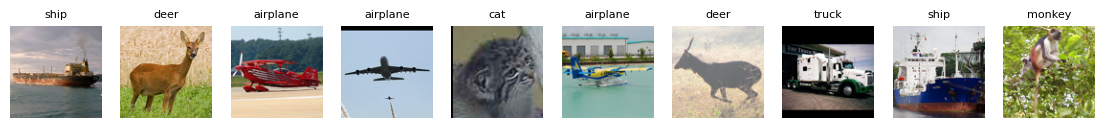

x: torch.Size([128, 3, 96, 96]) torch.float32
y: torch.Size([128]) torch.int64


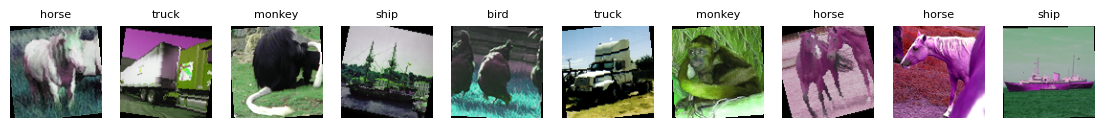

In [6]:
def make_loaders(
    ds_train_aug,
    ds_train_eval,
    ds_test,
    batch_size: int = BATCH_SIZE,
    val_ratio: float = 0.2,
    seed: int = RANDOM_STATE,
    fast_mode: bool = FAST_MODE,
):
    # train/val split
    n_total = len(ds_train_eval)
    n_val = int(n_total * val_ratio)
    n_train = n_total - n_val
    
    rng = np.random.RandomState(seed)
    indices = np.arange(n_total)
    rng.shuffle(indices)

    val_idx = indices[:n_val]
    train_idx = indices[n_val:]

    # Возьмём оба варианта
    ds_train_tr = Subset(ds_train_aug, train_idx)
    ds_train_clean = Subset(ds_train_eval, train_idx)
    ds_val = Subset(ds_train_eval, val_idx)

    # FAST_MODE: уменьшаем размер для скорости
    if fast_mode:
        train_idx2 = rng.choice(len(ds_train_tr), size=min(6000, len(ds_train_tr)), replace=False)
        val_idx2 = rng.choice(len(ds_val), size=min(1500, len(ds_val)), replace=False)
        test_idx2 = rng.choice(len(ds_test), size=min(1500, len(ds_test)), replace=False)

        ds_train_tr = Subset(ds_train_tr, train_idx2)
        ds_train_clean = Subset(ds_train_clean, train_idx2)
        ds_val = Subset(ds_val, val_idx2)
        ds_test_small = Subset(ds_test, test_idx2)
    else:
        ds_test_small = ds_test

    train_loader_aug = DataLoader(ds_train_tr, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    train_loader_clean = DataLoader(ds_train_clean, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(ds_test_small, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader_clean, train_loader_aug, val_loader, test_loader

train_loader_clean, train_loader_aug, val_loader, test_loader = make_loaders(ds_train_aug, ds_train_eval, ds_test)
for i in [train_loader_clean, train_loader_aug, val_loader, test_loader]:
    print(len(i))
#sanity check
batch = next(iter(train_loader_clean))
x, y = batch
print("x:", x.shape, x.dtype)
print("y:", y.shape, y.dtype)
show_images(train_loader_clean, n=10)
batch = next(iter(train_loader_aug))
x, y = batch
print("x:", x.shape, x.dtype)
print("y:", y.shape, y.dtype)
show_images(train_loader_aug, n=10, saveflag=True, filename=figures_dir / "augmentations_preview.png")

In [7]:
def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 96x96 -> 96x96
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 96x96 -> 48x48

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 48x48 -> 48x48
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 48x48 -> 24x24

            nn.Conv2d(64, 128, kernel_size=3, padding=1),# 24x24 -> 24x24
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 24x24 -> 12x12

            nn.Conv2d(128, 256, kernel_size=3, padding=1),# 12x12 -> 12x12
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 12x12 -> 6x6
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x

cnn = SimpleCNN(NUM_CLASSES).to(DEVICE)
print(cnn)
print("Trainable params:", count_params(cnn))

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=9216, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=10, bias=True)
  )
)
Trainable params: 5112650


In [8]:
# Быстрый sanity-check по shape
with torch.no_grad():
    x0 = torch.randn(2, 3, 96, 96).to(DEVICE)
    y0 = cnn(x0)
print("Input:", x0.shape, "Output logits:", y0.shape)

Input: torch.Size([2, 3, 96, 96]) Output logits: torch.Size([2, 10])


In [9]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 5, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – обычно это признак проблем с LR/стабильностью. Останавливаем обучение.")
            break

    return history

def plot_history(hist: Dict[str, List[float]], title: str = "", saveflag: bool = False, filename: Path = Path("")) -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    if saveflag:
        plt.savefig(filename)
    plt.show()

# C1


Experiment C1 | lr=0.001 weight_decay=0.0 epochs=12
Trainable params: 5112650
Epoch 01/12 | train loss 1.9421, acc 0.266 | val loss 1.6834, acc 0.365 | 1.1s
Epoch 02/12 | train loss 1.5509, acc 0.412 | val loss 1.4712, acc 0.434 | 1.0s
Epoch 03/12 | train loss 1.3545, acc 0.492 | val loss 1.4076, acc 0.475 | 1.0s
Epoch 04/12 | train loss 1.1971, acc 0.551 | val loss 1.2463, acc 0.531 | 1.0s
Epoch 05/12 | train loss 1.0319, acc 0.621 | val loss 1.2459, acc 0.557 | 1.0s
Epoch 06/12 | train loss 0.8911, acc 0.681 | val loss 1.2882, acc 0.556 | 1.0s
Epoch 07/12 | train loss 0.7432, acc 0.744 | val loss 1.3518, acc 0.549 | 1.0s
Epoch 08/12 | train loss 0.5881, acc 0.789 | val loss 1.3112, acc 0.588 | 1.0s
Epoch 09/12 | train loss 0.4150, acc 0.855 | val loss 1.3394, acc 0.595 | 1.0s
Epoch 10/12 | train loss 0.2582, acc 0.908 | val loss 1.7438, acc 0.589 | 1.0s
Epoch 11/12 | train loss 0.1992, acc 0.931 | val loss 1.8479, acc 0.559 | 1.0s
Epoch 12/12 | train loss 0.1222, acc 0.960 | val los

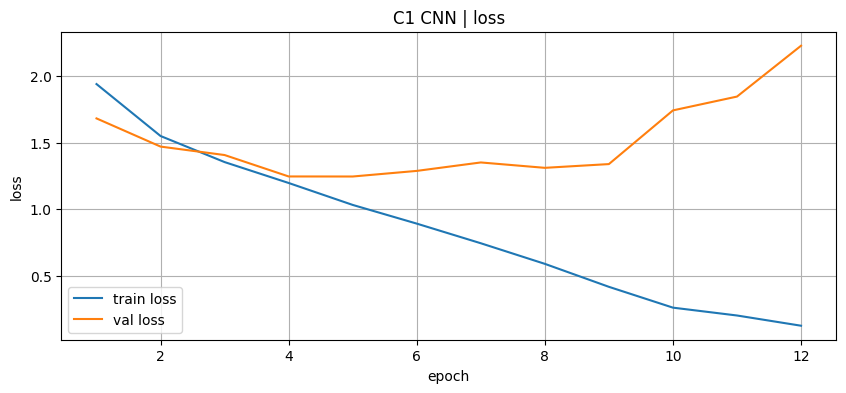

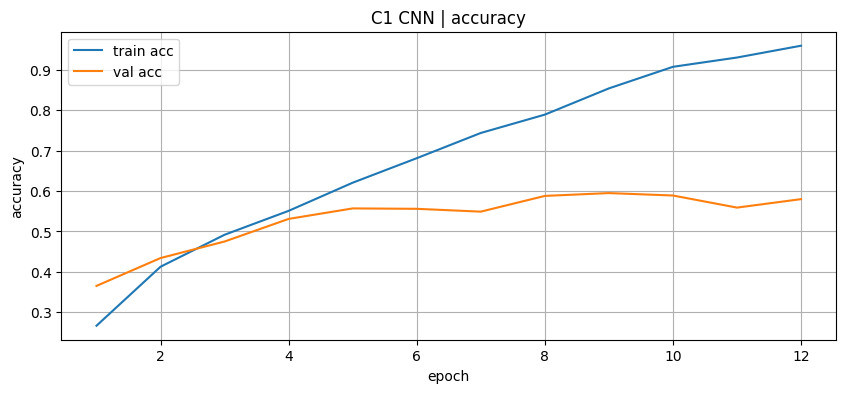

In [10]:
criterion = nn.CrossEntropyLoss()
def run_experiment(exp_id: str, model: nn.Module, train_loader, val_loader, lr: float = 1e-3, weight_decay: float = 0.0, epochs: int = EPOCHS):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    print("\n" + "=" * 80)
    print(f"Experiment {exp_id} | lr={lr} weight_decay={weight_decay} epochs={epochs}")
    print("Trainable params:", count_params(model))

    hist = fit(model, train_loader, val_loader, optimizer, criterion, epochs=epochs, verbose=True)
    best_val_acc = float(np.nanmax(hist["val_acc"])) if len(hist["val_acc"]) else float("nan")

    return {"exp_id": exp_id, "model": model, "history": hist, "best_val_acc": best_val_acc}
# Используем ЧИСТЫЙ loader
res_cnn_c1 = run_experiment("C1", SimpleCNN(NUM_CLASSES), train_loader_clean, val_loader, lr=1e-3, epochs=EPOCHS)
plot_history(res_cnn_c1["history"], title="C1 CNN")
eval_run(
    eid="C1",
    task="classification",
    model_summary="(simple-cnn-base): простая CNN без аугментаций",
    seed=42,
    dataset="STL10",
    optimizer="Adam",
    lr=1e-3,
    epochs_trained=12,
    best_val_accuracy=res_cnn_c1["best_val_acc"],
    test_accuracy=None,
    precision=None,
    recall=None,
    mean_iou=None,
    notes=""
)

# C2

In [11]:
cnn = SimpleCNN(NUM_CLASSES).to(DEVICE)
print(cnn)
print("Trainable params:", count_params(cnn))

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=9216, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=10, bias=True)
  )
)
Trainable params: 5112650


In [12]:
# Быстрый sanity-check по shape
with torch.no_grad():
    x0 = torch.randn(2, 3, 96, 96).to(DEVICE)
    y0 = cnn(x0)
print("Input:", x0.shape, "Output logits:", y0.shape)

Input: torch.Size([2, 3, 96, 96]) Output logits: torch.Size([2, 10])



Experiment C2 | lr=0.001 weight_decay=0.0 epochs=12
Trainable params: 5112650
Epoch 01/12 | train loss 2.0997, acc 0.224 | val loss 1.7643, acc 0.339 | 2.8s
Epoch 02/12 | train loss 1.6910, acc 0.364 | val loss 1.5141, acc 0.431 | 2.8s
Epoch 03/12 | train loss 1.4959, acc 0.434 | val loss 1.4763, acc 0.454 | 2.7s
Epoch 04/12 | train loss 1.3779, acc 0.479 | val loss 1.3967, acc 0.472 | 2.7s
Epoch 05/12 | train loss 1.3018, acc 0.507 | val loss 1.3290, acc 0.503 | 2.7s
Epoch 06/12 | train loss 1.1851, acc 0.562 | val loss 1.3123, acc 0.528 | 2.7s
Epoch 07/12 | train loss 1.0914, acc 0.608 | val loss 1.2167, acc 0.553 | 2.7s
Epoch 08/12 | train loss 1.0010, acc 0.639 | val loss 1.2293, acc 0.554 | 2.7s
Epoch 09/12 | train loss 0.9084, acc 0.668 | val loss 1.2569, acc 0.535 | 2.7s
Epoch 10/12 | train loss 0.8246, acc 0.705 | val loss 1.1954, acc 0.570 | 2.8s
Epoch 11/12 | train loss 0.7045, acc 0.743 | val loss 1.2879, acc 0.582 | 2.7s
Epoch 12/12 | train loss 0.6405, acc 0.767 | val los

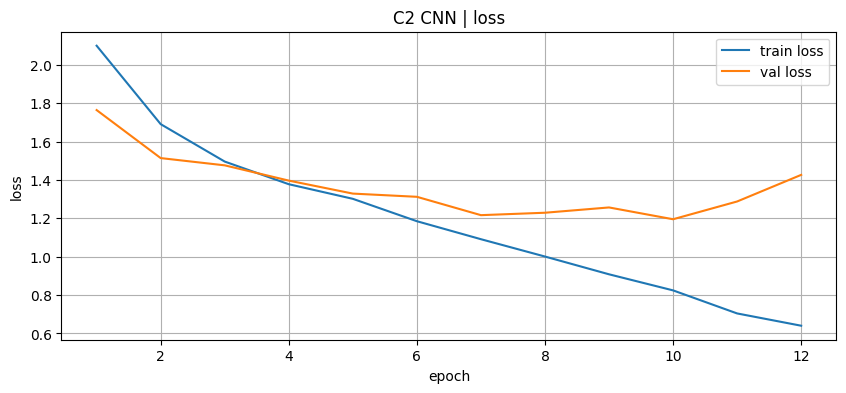

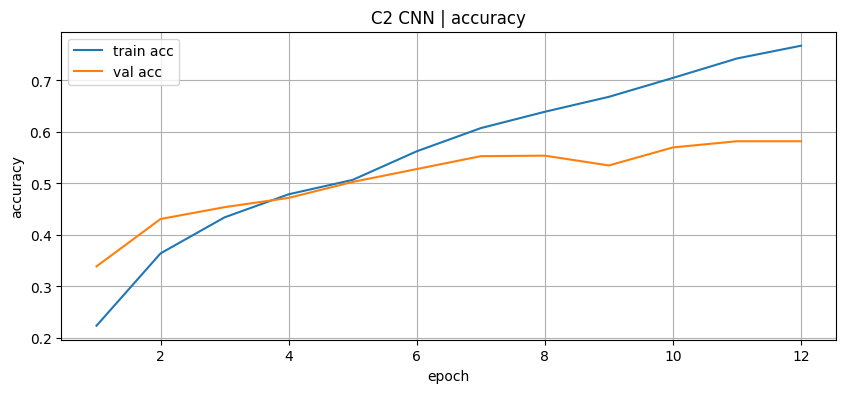

In [13]:
criterion = nn.CrossEntropyLoss()
set_seed(RANDOM_STATE)
# Используем loader С АУГМЕНТАЦИЯМИ
res_cnn_c2 = run_experiment("C2", SimpleCNN(NUM_CLASSES), train_loader_aug, val_loader, lr=1e-3, epochs=EPOCHS)
plot_history(res_cnn_c2["history"], title="C2 CNN")
eval_run(
    eid="C2",
    task="classification",
    model_summary="(simple-cnn-aug): та же CNN, но с разумными аугментациями",
    seed=42,
    dataset="STL10",
    optimizer="Adam",
    lr=1e-3,
    epochs_trained=12,
    best_val_accuracy=res_cnn_c2["best_val_acc"],
    test_accuracy=None,
    precision=None,
    recall=None,
    mean_iou=None,
    notes="добавлены аугментации colorjitter и randomrotation"
)

# C3

In [14]:
from torchvision.models import resnet18, ResNet18_Weights
BATCH_SIZE = 64  # ResNet тяжелее, чем SimpleCNN
EPOCHS_HEAD = 3 if FAST_MODE else 8
EPOCHS_FT   = 3 if FAST_MODE else 8

In [15]:
def get_resnet18_weights():
    # Пытаемся взять предобученные веса. Если не получилось – вернем None.
    try:
        w = ResNet18_Weights.DEFAULT
        # иногда ошибка возникает не здесь, а при фактической загрузке весов;
        # но на практике этого достаточно как "правильный путь".
        return w
    except Exception as e:
        print("Не удалось получить веса ResNet18_Weights.DEFAULT. Причина:", repr(e))
        return None

weights = get_resnet18_weights()
print("weights:", weights)

weights: ResNet18_Weights.IMAGENET1K_V1


In [16]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)
IMG_SIZE = 224
train_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
]) 
def load_stl10_tl(data_dir: str = DATA_DIR):
    ds_train_aug  = torchvision.datasets.STL10(root=data_dir, split="train", download=True, transform=train_tf)
    ds_train_eval = torchvision.datasets.STL10(root=data_dir, split="train", download=True, transform=eval_tf)
    ds_test       = torchvision.datasets.STL10(root=data_dir, split="test", download=True, transform=eval_tf)
    return ds_train_aug, ds_train_eval, ds_test
    
ds_train_aug, ds_train_eval, ds_test = load_stl10_tl()
class_names = ds_train_aug.classes
print("Train full:", len(ds_train_aug))
print("Test:", len(ds_test))

Train full: 5000
Test: 8000


In [17]:
def make_loaders_tl(
    ds_train_aug,
    ds_train_eval,
    ds_test,
    batch_size: int = BATCH_SIZE,
    val_ratio: float = 0.2,
    seed: int = RANDOM_STATE,
    fast_mode: bool = FAST_MODE,
):
    n_total = len(ds_train_aug)
    n_val = int(n_total * val_ratio)

    rng = np.random.RandomState(seed)
    indices = np.arange(n_total)
    rng.shuffle(indices)

    val_idx = indices[:n_val]
    train_idx = indices[n_val:]

    ds_train = Subset(ds_train_aug, train_idx)
    ds_val   = Subset(ds_train_eval, val_idx)

    if fast_mode:
        train_idx2 = rng.choice(len(ds_train), size=min(4000, len(ds_train)), replace=False)
        val_idx2   = rng.choice(len(ds_val), size=min(1000, len(ds_val)), replace=False)
        test_idx2  = rng.choice(len(ds_test), size=min(1000, len(ds_test)), replace=False)

        ds_train = Subset(ds_train, train_idx2)
        ds_val   = Subset(ds_val, val_idx2)
        ds_test_small = Subset(ds_test, test_idx2)
    else:
        ds_test_small = ds_test

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(ds_test_small, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders_tl(ds_train_aug, ds_train_eval, ds_test)

x, y = next(iter(train_loader))
print("x:", x.shape, x.dtype)
print("y:", y.shape, y.dtype)

x: torch.Size([64, 3, 224, 224]) torch.float32
y: torch.Size([64]) torch.int64


In [18]:
def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def build_resnet18(num_classes: int = 10, weights=weights) -> nn.Module:
    # Внимание: реальная загрузка весов может требовать интернет.
    # Если не получается – используйте weights=None.
    try:
        model = resnet18(weights=weights)
    except Exception as e:
        print("Не удалось загрузить предобученные веса. Переходим на weights=None. Причина:", repr(e))
        model = resnet18(weights=None)

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def set_requires_grad(module: nn.Module, flag: bool) -> None:
    for p in module.parameters():
        p.requires_grad = flag

model = build_resnet18(num_classes=10, weights=weights).to(DEVICE)
print(model)
print("Trainable params:", count_trainable_params(model))
     

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [19]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

def get_lr(optimizer) -> float:
    return float(optimizer.param_groups[0]["lr"])

def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 5, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        history["lr"].append(get_lr(optimizer))

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"lr {get_lr(optimizer):.2e} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – останавливаем обучение.")
            break

    return history

def plot_history(hist: Dict[str, List[float]], title: str = "", saveflag: bool = False, filename: Path = Path("")) -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    if saveflag:
        plt.savefig(filename)
    plt.show()

    plt.figure(figsize=(10, 3))
    plt.plot(epochs, hist["lr"], label="lr")
    plt.xlabel("epoch")
    plt.ylabel("lr")
    plt.title(title + " | lr")
    plt.grid(True)
    plt.legend()
    
    plt.show()

Trainable params (head-only): 5130

Phase 1: head-only training
Epoch 01/12 | lr 1.00e-03 | train loss 1.0788, acc 0.725 | val loss 0.4706, acc 0.892 | 3.2s
Epoch 02/12 | lr 1.00e-03 | train loss 0.3967, acc 0.912 | val loss 0.3167, acc 0.912 | 3.3s
Epoch 03/12 | lr 1.00e-03 | train loss 0.3027, acc 0.925 | val loss 0.2587, acc 0.919 | 3.3s
Epoch 04/12 | lr 1.00e-03 | train loss 0.2493, acc 0.936 | val loss 0.2286, acc 0.930 | 3.3s
Epoch 05/12 | lr 1.00e-03 | train loss 0.2230, acc 0.941 | val loss 0.2180, acc 0.927 | 3.3s
Epoch 06/12 | lr 1.00e-03 | train loss 0.2062, acc 0.942 | val loss 0.2119, acc 0.936 | 3.3s
Epoch 07/12 | lr 1.00e-03 | train loss 0.1898, acc 0.948 | val loss 0.1977, acc 0.937 | 3.3s
Epoch 08/12 | lr 1.00e-03 | train loss 0.1736, acc 0.954 | val loss 0.2029, acc 0.936 | 3.3s
Epoch 09/12 | lr 1.00e-03 | train loss 0.1689, acc 0.950 | val loss 0.1845, acc 0.940 | 3.3s
Epoch 10/12 | lr 1.00e-03 | train loss 0.1633, acc 0.949 | val loss 0.1916, acc 0.936 | 3.2s
Epoch 

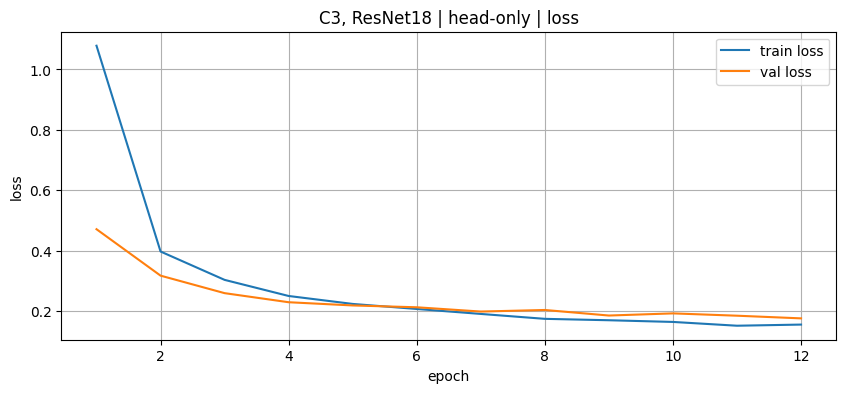

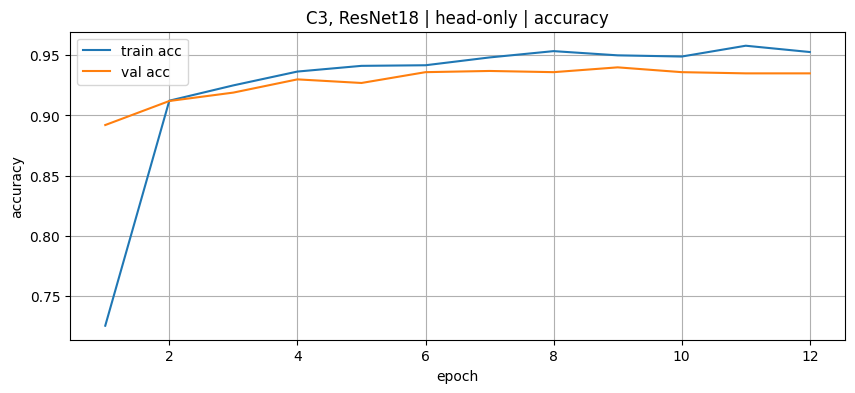

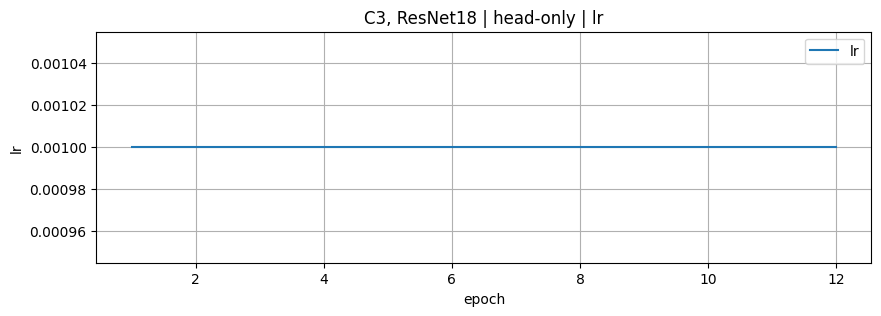

In [20]:
criterion = nn.CrossEntropyLoss()
set_seed(RANDOM_STATE)
model_head = build_resnet18(num_classes=10, weights=weights).to(DEVICE)

# freeze всё
set_requires_grad(model_head, False)
# размораживаем только голову
set_requires_grad(model_head.fc, True)

print("Trainable params (head-only):", count_trainable_params(model_head))

optimizer_head = torch.optim.Adam(model_head.fc.parameters(), lr=1e-3)

print("\n" + "=" * 80)
print("Phase 1: head-only training")
# CLEAN loader
set_seed(RANDOM_STATE)
hist_head = fit(model_head, train_loader, val_loader, optimizer_head, criterion, epochs=12, verbose=True)
plot_history(hist_head, title="C3, ResNet18 | head-only")
eval_run(
    eid="C3",
    task="classification",
    model_summary="ResNet18 с pretrained weights; backbone заморожен, обучается только классификационная голова",
    seed=42,
    dataset="STL10",
    optimizer="Adam",
    lr=1e-3,
    epochs_trained=12,
    best_val_accuracy=max(hist_head["val_acc"]),
    test_accuracy=None,
    precision=None,
    recall=None,
    mean_iou=None,
    notes=""
)


# C4

Trainable params (layer4+fc): 8398858

Phase 2: fine-tuning layer4 + fc
Epoch 01/12 | lr 1.00e-04 | train loss 0.1680, acc 0.943 | val loss 0.2361, acc 0.928 | 3.3s
Epoch 02/12 | lr 1.00e-04 | train loss 0.0851, acc 0.973 | val loss 0.1600, acc 0.949 | 3.3s
Epoch 03/12 | lr 1.00e-04 | train loss 0.0514, acc 0.986 | val loss 0.1599, acc 0.948 | 3.3s
Epoch 04/12 | lr 1.00e-04 | train loss 0.0371, acc 0.988 | val loss 0.1856, acc 0.942 | 3.4s
Epoch 05/12 | lr 1.00e-04 | train loss 0.0271, acc 0.992 | val loss 0.1711, acc 0.942 | 3.4s
Epoch 06/12 | lr 1.00e-04 | train loss 0.0243, acc 0.993 | val loss 0.1829, acc 0.946 | 3.4s
Epoch 07/12 | lr 1.00e-04 | train loss 0.0178, acc 0.995 | val loss 0.1823, acc 0.943 | 3.4s
Epoch 08/12 | lr 1.00e-04 | train loss 0.0173, acc 0.995 | val loss 0.1807, acc 0.943 | 3.4s
Epoch 09/12 | lr 1.00e-04 | train loss 0.0161, acc 0.995 | val loss 0.2093, acc 0.943 | 3.4s
Epoch 10/12 | lr 1.00e-04 | train loss 0.0135, acc 0.997 | val loss 0.2208, acc 0.941 | 3.4

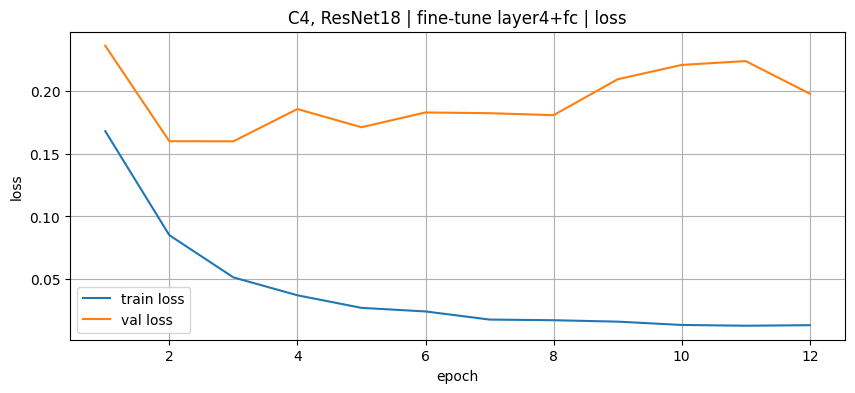

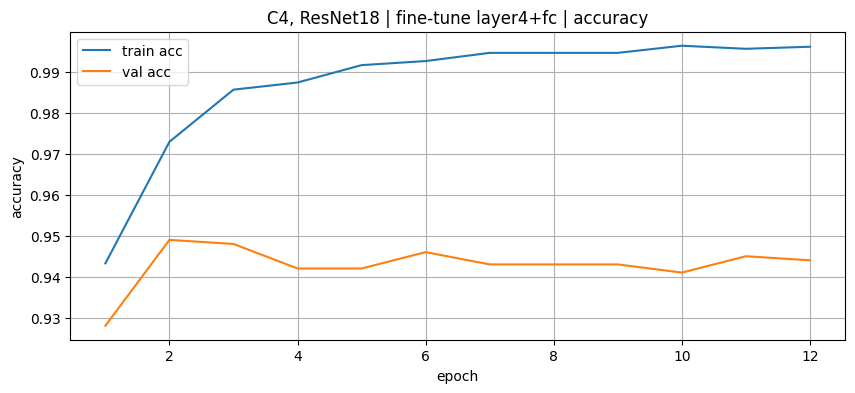

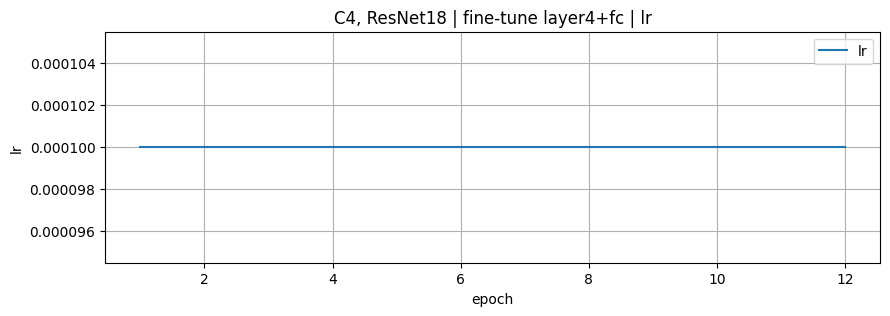

Test acc: 0.948


In [21]:
# размораживаем layer4 и fc
criterion = nn.CrossEntropyLoss()
set_seed(RANDOM_STATE)
set_requires_grad(model_head.layer4, True)
set_requires_grad(model_head.fc, True)

print("Trainable params (layer4+fc):", count_trainable_params(model_head))

# param groups: backbone меньше, head больше
params = [
    {"params": model_head.layer4.parameters(), "lr": 1e-4},
    {"params": model_head.fc.parameters(), "lr": 1e-3},
]

optimizer_ft = torch.optim.Adam(params, weight_decay=1e-4)

print("\n" + "=" * 80)
print("Phase 2: fine-tuning layer4 + fc")
set_seed(RANDOM_STATE)
hist_ft = fit(model_head, train_loader, val_loader, optimizer_ft, criterion, epochs=12, verbose=True)
tmp_path = artifacts_dir / 'best_classifier.pt'
torch.save(model_head.state_dict(), tmp_path)
res_cnn_c4 = plot_history(hist_ft, title="C4, ResNet18 | fine-tune layer4+fc", saveflag=True, filename=figures_dir / "classification_curves_best.png")
@torch.no_grad()
def accuracy_on_loader(model, loader) -> float:
    model.eval()
    total_correct, total_seen = 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += y.size(0)
    return total_correct / total_seen

test_acc = accuracy_on_loader(model_head, test_loader)
print("Test acc:", round(test_acc, 4))
eval_run(
    eid="C4",
    task="classification",
    model_summary="ResNet18 с pretrained weights; частичное fine-tune",
    seed=42,
    dataset="STL10",
    optimizer="Adam",
    lr=1e-4,
    epochs_trained=12,
    best_val_accuracy=max(hist_ft["val_acc"]),
    test_accuracy=test_acc,
    precision=None,
    recall=None,
    mean_iou=None,
    notes="lr указан для layer4, для fc и optim - 1e-3 "
)
c4_desc_blob = {
    "experiment_id":"C4",
    "model":"resnet18-ft",
    "dataset":"STL10",
    "seed":42,
    "batch_size": 64,
    "transforms": {
        "train": [
            "Resize(256)",
            "RandomResizedCrop(224, scale=(0.7, 1.0))",
            "RandomHorizontalFlip(p=0.5)",
            "ToTensor()",
            "Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))"
        ],
        "eval": [
            "Resize(256)",
            "CenterCrop(224)",
            "ToTensor()",
            "Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))"
        ]
    },
    "optimizer": "Adam",
    "lr": {
        "layer4":1e-4,
        "fc":1e-3,
        "optimizer-ft": 1e-3
    },
    "fc":"nn.Linear",
    "weight_decay":1e-4,
    "epochs_trained":12,
    "notes":"ResNet18 с pretrained weights; частичное fine-tune (layer4 + fc). Значения для transforms.Normalize взяты стандартные."
}
save_json(c4_desc_blob,artifacts_dir / "best_classifier_config.json" )
# C4 - лучшая модель

# Сравнение

[0.595, 0.582, 0.94, 0.949]


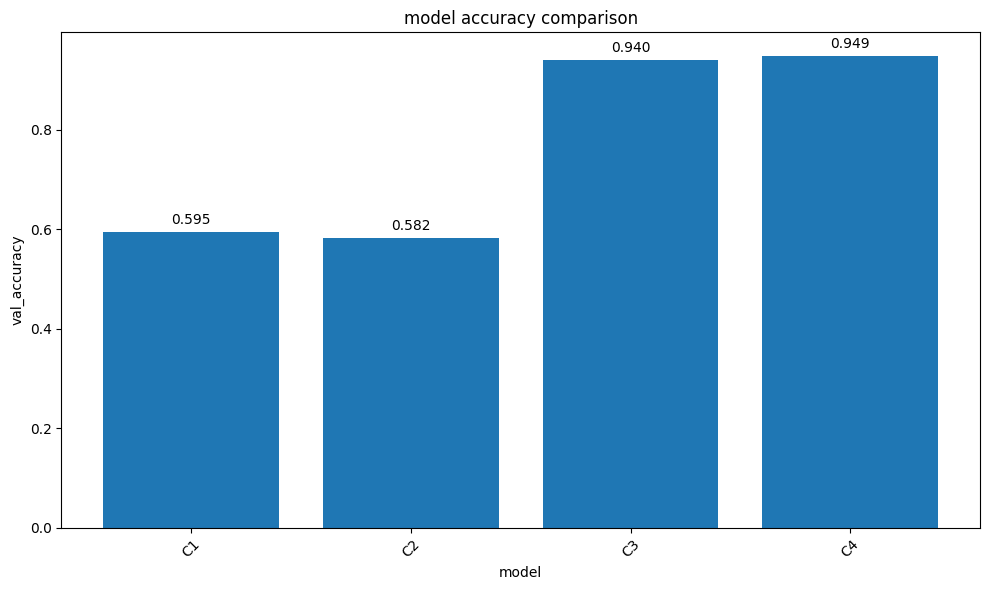

In [22]:
accuracies = [i['best_val_accuracy'] for i in runs if "C" in i['experiment_id']] # :-)
print(accuracies)
def plot_accuracies(accuracies, model_names=None, saveflag: bool = False, filename: Path = Path("")):
    names = [f"C{i+1}" for i in range(len(accuracies))]
    plt.figure(figsize=(10, 6))
    plt.bar(names, accuracies)
    plt.title('model accuracy comparison')
    plt.xlabel('model')
    plt.ylabel('val_accuracy')
    plt.xticks(rotation=45)
    for i, v in enumerate(accuracies):
        plt.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
    plt.tight_layout()
    if saveflag:
        plt.savefig(filename)
    plt.show()
    
plot_accuracies(accuracies=accuracies, saveflag=True, filename = figures_dir / "classification_compare.png")

# Часть B

# V1

In [23]:
score_threshold = 0.3 

In [24]:
from typing import List, Dict, Tuple, Optional
import torch.utils.data
from PIL import Image
from torchvision.transforms import ToTensor

In [25]:
pascal_df = torchvision.datasets.VOCDetection(root="./data", download=True)

In [26]:
# В общем для меня эта часть оказалась достаточно сложной, так как необходимо было очень грамотно разобраться с задачей.
# По ТЗ дано два способа решения: детекция всего что есть по меткам модели ИЛИ детекция всего, что есть теоретически только в изображении (из общих меток), 
# и никаких лишних объектов из загруженных меток модели. Я остановился именно на втором варианте.

from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights
try:
    weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
except Exception as e:
    print("Не удалось получить веса FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT. Причина:", repr(e))
    weights = None

weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn_v2(weights=weights).to(DEVICE) 
categories = weights.meta.get("categories", None)
loaded_labels = {} # загруженные из модели метки
real_labels = {} # загруженные из датасета метки
mutual_categories = {} # общие категории (пока что только заготовка)
person_label = None

# Для каждого изображения нужно детектить именно те объекты, которые находятся в метках изображений датасета
# Для этого нужно оставить только метки, содержащиеся в изображениях и для каждого изображения ожидать, что в нем будут только метки из набора нужных общих меток
# Удаляем из загруженных из модели меток все метки, которых нет в датасете

# Загрузка меток из датасетаы
for i in range(len(pascal_df)):
    item = pascal_df[i][1]["annotation"]["object"]
    for j in item:
        real_labels[j["name"]] = True # placeholder
print("real:",real_labels) # из датасета
print("model_labels:",categories) # из модели

for i in real_labels:
    if categories and i in categories:
        mutual_categories[i] = categories.index(i) # общие категории
    if i not in categories:
        print(f"Label {i} not found")
        
print("current_labels", mutual_categories)
print("loaded:",str(len(mutual_categories))+f"/{len(real_labels)}")

# не найдены: tvmonitor, aeroplane, diningtable, pottedplant, sofa, motorbike из real_labels
# в то время как в categories есть: tv, airplane, dining table (с пробелом), potted plant (с пробелом), 
# couch (почти sofa (я более чем уверен)), motorcycle

# вручную нужно их добавить сохраняя их под именем меток из датасета
# это можно было бы сделать легче и 'красивше' через map
mutual_categories["tvmonitor"] = categories.index("tv")
mutual_categories["aeroplane"] = categories.index("airplane")
mutual_categories["diningtable"] = categories.index("dining table")
mutual_categories["pottedplant"] = categories.index("potted plant")
mutual_categories["sofa"] = categories.index("couch")
mutual_categories["motorbike"] = categories.index("motorcycle")

# второй проход
print("второй проход")
for i in real_labels:
    if categories and i in categories:
        mutual_categories[i] = categories.index(i) # общие категории
    if i not in categories:
        print(f"Label {i} not found")

model.eval()
print("model: fastercnn_resnet50_fpn_v2")
print("current_labels", mutual_categories)
print("loaded:",str(len(mutual_categories))+f"/{len(real_labels)}")

real: {'horse': True, 'person': True, 'bottle': True, 'dog': True, 'tvmonitor': True, 'car': True, 'aeroplane': True, 'bicycle': True, 'boat': True, 'chair': True, 'diningtable': True, 'pottedplant': True, 'train': True, 'cat': True, 'sofa': True, 'bird': True, 'sheep': True, 'motorbike': True, 'bus': True, 'cow': True}
model_labels: ['__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'co

In [27]:
class PascalVOCDataset(torch.utils.data.Dataset):
    def __init__(self, root: str):
        self.root = root
        self.df = pascal_df
        # преобразуем PIL -> torch.Tensor [0..1]
        self.to_tensor = ToTensor()

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        img = self.df[idx][0].convert("RGB")
        annotations = self.df[idx][1]["annotation"]
        objects = annotations["object"]
        boxes = []
        for i in objects:
            boxes.append([int(i["bndbox"]["xmin"]),int(i["bndbox"]["ymin"]),int(i["bndbox"]["xmax"]),int(i["bndbox"]["ymax"])])
        labels = []
        for i in range(len(objects)):
            loaded_labels_index = self.df[idx][1]["annotation"]["object"][i]["name"]
            labels.append(mutual_categories[loaded_labels_index]) # загрузить метку из mutual
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        #labels_old = torch.ones((boxes.shape[0],), dtype=torch.int64)  # в датасете только "person"
        image_id = torch.tensor([idx], dtype=torch.int64)
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        #iscrowd = torch.zeros((boxes.shape[0],), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": image_id,
            #"area": area,
        }

        img_t = self.to_tensor(img)
        return img_t, target

def collate_fn(batch):
    return tuple(zip(*batch))
    
ptt = transforms.ToTensor() # convert PIL to tensor
dataset = PascalVOCDataset("./data")
len(dataset), dataset[0], dataset[0][0].shape, dataset[0][1].keys(), dataset[0][1]["boxes"], dataset[0][1]["labels"]

(5717,
 (tensor([[[1.0000, 1.0000, 1.0000,  ..., 0.7922, 0.7961, 0.8000],
           [1.0000, 1.0000, 1.0000,  ..., 0.7961, 0.7961, 0.7922],
           [1.0000, 1.0000, 1.0000,  ..., 0.8078, 0.8039, 0.8039],
           ...,
           [0.8039, 0.7608, 0.8078,  ..., 0.5373, 0.4706, 0.4667],
           [0.7529, 0.7569, 0.7569,  ..., 0.4353, 0.4235, 0.4784],
           [0.6980, 0.7059, 0.7255,  ..., 0.3216, 0.2863, 0.3137]],
  
          [[1.0000, 1.0000, 1.0000,  ..., 0.8039, 0.8078, 0.8118],
           [1.0000, 1.0000, 1.0000,  ..., 0.8078, 0.8078, 0.8039],
           [1.0000, 1.0000, 1.0000,  ..., 0.8196, 0.8157, 0.8157],
           ...,
           [0.7490, 0.7059, 0.7529,  ..., 0.5020, 0.4392, 0.4431],
           [0.6980, 0.7020, 0.7020,  ..., 0.4157, 0.4039, 0.4667],
           [0.6431, 0.6510, 0.6706,  ..., 0.3020, 0.2667, 0.3020]],
  
          [[1.0000, 1.0000, 1.0000,  ..., 0.9725, 0.9765, 0.9804],
           [1.0000, 1.0000, 1.0000,  ..., 0.9765, 0.9765, 0.9725],
           [1.0

In [28]:
def draw_boxes(ax, boxes, color="r", linewidth=2, text=None):
    import matplotlib.patches as patches
    for i, b in enumerate(boxes):
        x1, y1, x2, y2 = [float(v) for v in b]
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 linewidth=linewidth, edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        if text is not None:
            ax.text(x1, y1, text(i), color=color, fontsize=10,
                    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"))
@torch.no_grad()
def predict_one(img_t: torch.Tensor) -> Dict[str, torch.Tensor]:
    out = model([img_t.to(DEVICE)])[0]
    out = {k: v.detach().cpu() for k, v in out.items()}
    return out

def filter_preds(pred: Dict[str, torch.Tensor], score_thr: float, correct_labels: Optional[List[int]] = None) -> Dict[str, torch.Tensor]:
    keep = pred["scores"] >= score_thr
    if correct_labels is not None and "labels" in pred:
        label_mask = torch.zeros_like(pred["labels"], dtype=torch.bool)
        for label in correct_labels:
            label_mask = label_mask | (pred["labels"] == label)
        keep = keep & label_mask
    return {k: v[keep] for k, v in pred.items()}

In [29]:
preds = [] # setting predictions here to not run the next cell every time
print(mutual_categories)

{'horse': 19, 'person': 1, 'bottle': 44, 'dog': 18, 'car': 3, 'bicycle': 2, 'boat': 9, 'chair': 62, 'train': 7, 'cat': 17, 'bird': 16, 'sheep': 20, 'bus': 6, 'cow': 21, 'tvmonitor': 72, 'aeroplane': 5, 'diningtable': 67, 'pottedplant': 64, 'sofa': 63, 'motorbike': 4}


3


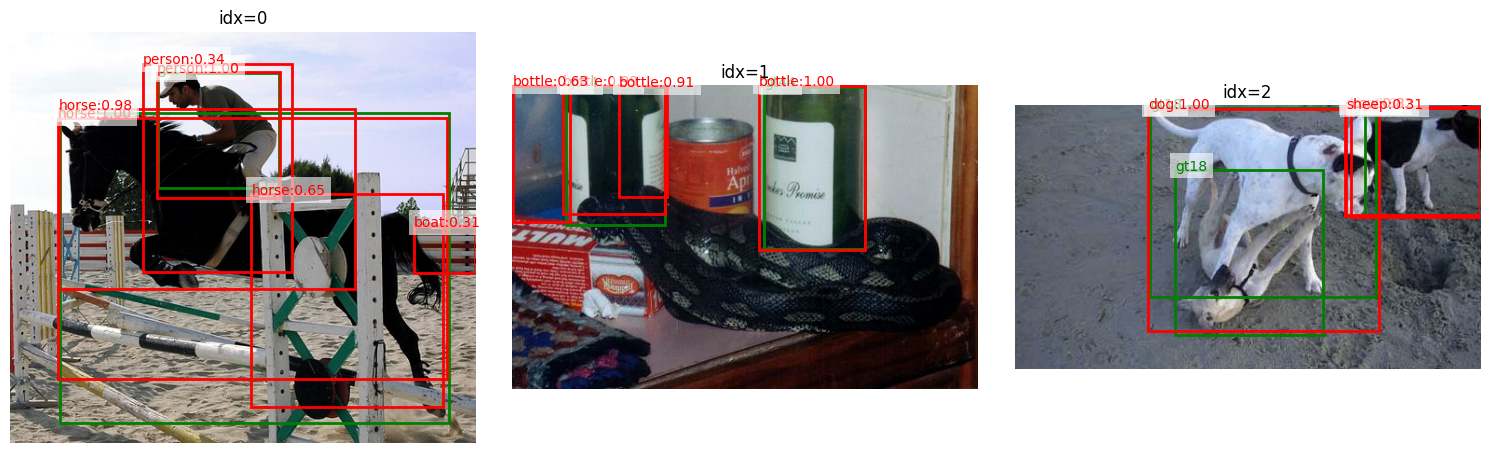

In [30]:
n = 3 # количество примеров
fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
for i in range(n):
    img_t, target = dataset[i] # limit range
    
    pred = predict_one(img_t) # сохранено в памяти # раскомент только при запуске всего ноутбука
    pred_f = filter_preds(pred, score_threshold, list(mutual_categories.values())) # порог взят из неиспользуемого класса, далее по заданию 
    preds.append(pred_f) # dont rerun # раскомент только при запуске всего ноутбука
    img_np = (img_t.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    # discard wrong labels
    ax = axes[i]
    ax.imshow(img_np)
    ax.set_title(f"idx={i}")
    ax.axis("off")

    # GT - зелёный, Pred - красный
    draw_boxes(ax, target["boxes"], color="g", linewidth=2, text=lambda j: f"gt{target['labels'][j]}")
    draw_boxes(ax, pred_f["boxes"], color="r", linewidth=2, text=lambda j: f"{categories[pred_f['labels'][j]]}:{pred_f['scores'][j]:.2f}")
print(len(preds))
plt.tight_layout()
plt.savefig(figures_dir / "detection_examples.png")
plt.show()

In [31]:
from tqdm import tqdm
def box_iou_matrix(boxes1: torch.Tensor, boxes2: torch.Tensor) -> torch.Tensor:
    '''
    boxes: [N,4] and [M,4] in (x1,y1,x2,y2), returns [N,M]
    '''
    if boxes1.numel() == 0 or boxes2.numel() == 0:
        return torch.zeros((boxes1.shape[0], boxes2.shape[0]), dtype=torch.float32)

    x1 = torch.max(boxes1[:, None, 0], boxes2[None, :, 0])
    y1 = torch.max(boxes1[:, None, 1], boxes2[None, :, 1])
    x2 = torch.min(boxes1[:, None, 2], boxes2[None, :, 2])
    y2 = torch.min(boxes1[:, None, 3], boxes2[None, :, 3])

    inter = (x2 - x1).clamp(min=0) * (y2 - y1).clamp(min=0)

    area1 = (boxes1[:, 2] - boxes1[:, 0]).clamp(min=0) * (boxes1[:, 3] - boxes1[:, 1]).clamp(min=0)
    area2 = (boxes2[:, 2] - boxes2[:, 0]).clamp(min=0) * (boxes2[:, 3] - boxes2[:, 1]).clamp(min=0)

    union = area1[:, None] + area2[None, :] - inter + 1e-9
    return inter / union

def match_greedy(pred_boxes: torch.Tensor, pred_scores: torch.Tensor, gt_boxes: torch.Tensor, iou_thr: float) -> Tuple[int, int, int, float]:
    '''
    Жадный матчинг: идём по pred по убыванию score, матчим к лучшему ещё не занятому GT.
    Возвращаем TP, FP, FN и средний IoU по матчам.
    '''
    if pred_boxes.numel() == 0:
        tp, fp, fn = 0, 0, int(gt_boxes.shape[0])
        return tp, fp, fn, float("nan")

    order = torch.argsort(pred_scores, descending=True)
    pred_boxes = pred_boxes[order]
    pred_scores = pred_scores[order]

    iou = box_iou_matrix(pred_boxes, gt_boxes)  # [P,G]
    gt_used = torch.zeros((gt_boxes.shape[0],), dtype=torch.bool)

    tp = 0
    fp = 0
    ious = []

    for p in range(pred_boxes.shape[0]):
        if gt_boxes.shape[0] == 0:
            fp += 1
            continue
        best_iou, best_j = torch.max(iou[p], dim=0)
        best_iou = float(best_iou.item())
        best_j = int(best_j.item())

        if best_iou >= iou_thr and not gt_used[best_j]:
            tp += 1
            gt_used[best_j] = True
            ious.append(best_iou)
        else:
            fp += 1

    fn = int((~gt_used).sum().item())
    mean_iou = float(np.mean(ious)) if len(ious) else float("nan")
    return tp, fp, fn, mean_iou

def evaluate_subset(indices: List[int], pred_thr: float) -> Dict[str, float]:
    tps = fps = fns = 0
    ious = []
    pbar = tqdm(indices, desc="Обработка изображений", unit="img") # REMOVE ME
    for idx in pbar: # REPLACE PBAR WITH INDICES
        img_t, target = dataset[idx]
        pred = predict_one(img_t)
        pred_f = filter_preds(pred, pred_thr, list(mutual_categories.values()))

        tp, fp, fn, miou = match_greedy(pred_f["boxes"], pred_f["scores"], target["boxes"], 0.5)
        tps += tp
        fps += fp
        fns += fn
        if math.isfinite(miou):
            ious.append(miou)

    precision = tps / (tps + fps + 1e-9)
    recall = tps / (tps + fns + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    mean_iou = float(np.mean(ious)) if len(ious) else float("nan")

    return {
        "TP": float(tps),
        "FP": float(fps),
        "FN": float(fns),
        "precision@IoU": precision,
        "recall@IoU": recall,
        "F1@IoU": f1,
        "mean_IoU_matched": mean_iou,
    }

# Оцениваем небольшое подмножество (быстро), либо больше (если fast_mode=False)
FAST_MODE = False
if FAST_MODE:
    eval_indices = list(range(min(200, len(dataset)))) 
else:
    eval_indices = list(range(len(dataset))) 

metrics_v1 = evaluate_subset(eval_indices, score_threshold)
print(metrics_v1)
eval_run(
    eid="V1",
    task="detection",
    model_summary="inference при score_threshold = 0.3",
    seed=42,
    dataset="Pascal VOC",
    optimizer="",
    lr=None,
    epochs_trained=None,
    best_val_accuracy=None,
    test_accuracy=None,
    precision=metrics_v1['precision@IoU'],
    recall=metrics_v1['recall@IoU'],
    mean_iou=metrics_v1['mean_IoU_matched'],
    notes="score_threshold = 0.3"
)

Обработка изображений: 100%|████████████████████████████████████████████████████████████| 5717/5717 [07:40<00:00, 12.42img/s]

{'TP': 14510.0, 'FP': 16821.0, 'FN': 1264.0, 'precision@IoU': 0.4631195940123053, 'recall@IoU': 0.9198681374413008, 'F1@IoU': 0.6160704803951854, 'mean_IoU_matched': 0.8762351522061966}


# V2

In [32]:
score_threshold = 0.7

In [33]:
try:
    weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
except Exception as e:
    print("Не удалось получить веса FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT. Причина:", repr(e))
    weights = None
model = fasterrcnn_resnet50_fpn_v2(weights=weights).to(DEVICE) 
model.eval()
person_label = None
dataset = PascalVOCDataset("./data")
print(len(dataset))
print(mutual_categories)

5717
{'horse': 19, 'person': 1, 'bottle': 44, 'dog': 18, 'car': 3, 'bicycle': 2, 'boat': 9, 'chair': 62, 'train': 7, 'cat': 17, 'bird': 16, 'sheep': 20, 'bus': 6, 'cow': 21, 'tvmonitor': 72, 'aeroplane': 5, 'diningtable': 67, 'pottedplant': 64, 'sofa': 63, 'motorbike': 4}


In [34]:
def draw_boxes(ax, boxes, color="r", linewidth=2, text=None):
    import matplotlib.patches as patches
    for i, b in enumerate(boxes):
        x1, y1, x2, y2 = [float(v) for v in b]
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 linewidth=linewidth, edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        if text is not None:
            ax.text(x1, y1, text(i), color=color, fontsize=10,
                    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"))
@torch.no_grad()
def predict_one(img_t: torch.Tensor) -> Dict[str, torch.Tensor]:
    out = model([img_t.to(DEVICE)])[0]
    out = {k: v.detach().cpu() for k, v in out.items()}
    return out

In [35]:
preds = [] # setting predictions here to not run the next cell every time

In [36]:
print(len(dataset))

5717


3


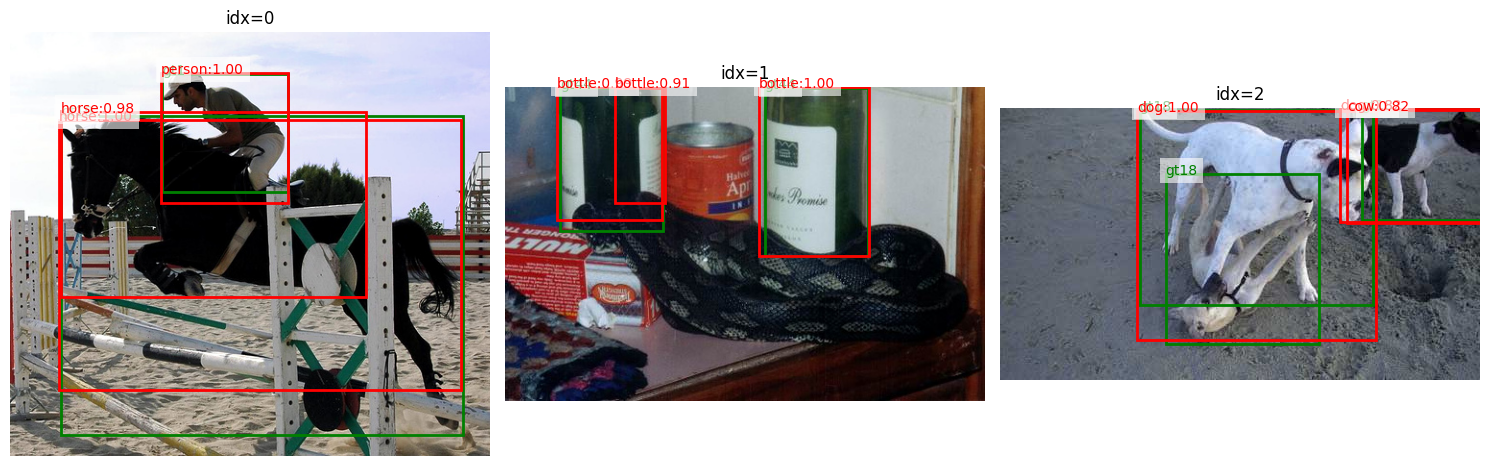

In [37]:
n = 3 # количество примеров
fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
for i in range(n):
    img_t, target = dataset[i] # limit range
    
    pred = predict_one(img_t) # сохранено в памяти # раскомент только при запуске всего ноутбука
    pred_f = filter_preds(pred, score_threshold, list(mutual_categories.values())) # порог взят из неиспользуемого класса, далее по заданию 
    preds.append(pred_f) # dont rerun # раскомент только при запуске всего ноутбука
    img_np = (img_t.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    # discard wrong labels
    ax = axes[i]
    ax.imshow(img_np)
    ax.set_title(f"idx={i}")
    ax.axis("off")

    # GT - зелёный, Pred - красный
    draw_boxes(ax, target["boxes"], color="g", linewidth=2, text=lambda j: f"gt{target['labels'][j]}")
    draw_boxes(ax, pred_f["boxes"], color="r", linewidth=2, text=lambda j: f"{categories[pred_f['labels'][j]]}:{pred_f['scores'][j]:.2f}")
print(len(preds))
plt.tight_layout()
plt.show()

In [38]:
eval_indices = list(range(len(dataset)))
metrics_v2 = evaluate_subset(eval_indices, score_threshold)
print(metrics_v2)

Обработка изображений: 100%|████████████████████████████████████████████████████████████| 5717/5717 [07:41<00:00, 12.39img/s]

{'TP': 13406.0, 'FP': 5173.0, 'FN': 2368.0, 'precision@IoU': 0.7215673609989385, 'recall@IoU': 0.8498795486242646, 'F1@IoU': 0.7804849644262933, 'mean_IoU_matched': 0.8804015555673431}


In [39]:
eval_run(
    eid="V2",
    task="detection",
    model_summary="inference при score_threshold = 0.7",
    seed=42,
    dataset="Pascal VOC",
    optimizer="",
    lr=None,
    epochs_trained=None,
    best_val_accuracy=None,
    test_accuracy=None,
    precision=metrics_v2['precision@IoU'],
    recall=metrics_v2['recall@IoU'],
    mean_iou=metrics_v2['mean_IoU_matched'],
    notes="score_threshold = 0.7"
)

# Артефакты метрик

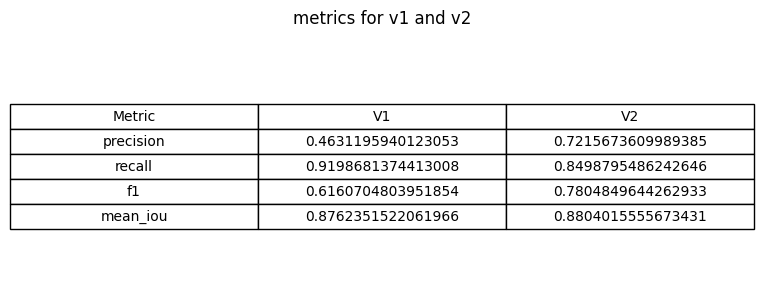

In [40]:
def save_metrics(metrics_v1, metrics_v2, saveflag: bool = False, filename: Path = ""):
    data = {
        'Metric': ['precision', 'recall', 'f1', 'mean_iou'],
        'V1': [
            metrics_v1['precision@IoU'],
            metrics_v1['recall@IoU'],
            metrics_v1['F1@IoU'],
            metrics_v1['mean_IoU_matched']
        ],
        'V2': [
            metrics_v2['precision@IoU'],
            metrics_v2['recall@IoU'],
            metrics_v2['F1@IoU'],
            metrics_v2['mean_IoU_matched']
        ]
    }
    df = pd.DataFrame(data)
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.axis('tight')
    ax.axis('off')
    table = ax.table(cellText=df.values,
                     colLabels=df.columns,
                     cellLoc='center',
                     loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)
    plt.title('metrics for v1 and v2', pad=20)
    if saveflag:
        plt.savefig(filename, dpi=150, bbox_inches='tight')    
    plt.show()
save_metrics(metrics_v1,metrics_v2,saveflag=True, filename=figures_dir / "detection_metrics.png")

# Заключение

In [41]:
print(runs)
df_s = pd.DataFrame(runs)
display(df_s)
df_s.to_csv(artifacts_dir / "runs.csv", index=False)

[{'experiment_id': 'C1', 'task': 'classification', 'dataset': 'STL10', 'seed': 42, 'model_summary': '(simple-cnn-base): простая CNN без аугментаций', 'optimizer': 'Adam', 'lr': 0.001, 'epochs_trained': 12, 'best_val_accuracy': 0.595, 'test_accuracy': None, 'precision': None, 'recall': None, 'mean_iou': None, 'notes': ''}, {'experiment_id': 'C2', 'task': 'classification', 'dataset': 'STL10', 'seed': 42, 'model_summary': '(simple-cnn-aug): та же CNN, но с разумными аугментациями', 'optimizer': 'Adam', 'lr': 0.001, 'epochs_trained': 12, 'best_val_accuracy': 0.582, 'test_accuracy': None, 'precision': None, 'recall': None, 'mean_iou': None, 'notes': 'добавлены аугментации colorjitter и randomrotation'}, {'experiment_id': 'C3', 'task': 'classification', 'dataset': 'STL10', 'seed': 42, 'model_summary': 'ResNet18 с pretrained weights; backbone заморожен, обучается только классификационная голова', 'optimizer': 'Adam', 'lr': 0.001, 'epochs_trained': 12, 'best_val_accuracy': 0.94, 'test_accuracy

,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,42,(simple-cnn-base): простая CNN без аугментаций,Adam,0.0010,12.0,0.595,NaN,NaN,NaN,NaN,
1,C2,classification,STL10,42,"(simple-cnn-aug): та же CNN, но с разумными ау...",Adam,0.0010,12.0,0.582,NaN,NaN,NaN,NaN,добавлены аугментации colorjitter и randomrota...
2,C3,classification,STL10,42,ResNet18 с pretrained weights; backbone заморо...,Adam,0.0010,12.0,0.940,NaN,NaN,NaN,NaN,
3,C4,classification,STL10,42,ResNet18 с pretrained weights; частичное fine-...,Adam,0.0001,12.0,0.949,0.948,NaN,NaN,NaN,"lr указан для layer4, для fc и optim - 1e-3"
4,V1,detection,Pascal VOC,42,inference при score_threshold = 0.3,,NaN,NaN,NaN,NaN,0.463120,0.919868,0.876235,score_threshold = 0.3
5,V2,detection,Pascal VOC,42,inference при score_threshold = 0.7,,NaN,NaN,NaN,NaN,0.721567,0.849880,0.880402,score_threshold = 0.7
